In [2]:
import matplotlib.pyplot as plt
import mrcfile
import torch

from cryosim.cryosparc_utils import extract_parameters_from_csfile
from cryosim.ghostbuster import Ghostbuster
from cryosim.progress import track
import gc


%load_ext autoreload
%autoreload 2

## Helper function to clear GPU memory

In [3]:
def clear_memory(*names):
    torch.cuda.synchronize()

    before_alloc = torch.cuda.memory_allocated()
    before_reserved = torch.cuda.memory_reserved()

    # delete requested globals
    for name in names:
        if name in globals():
            del globals()[name]

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    after_alloc = torch.cuda.memory_allocated()
    after_reserved = torch.cuda.memory_reserved()

    freed_alloc = (before_alloc - after_alloc) / 1024**2
    freed_reserved = (before_reserved - after_reserved) / 1024**2

    print(f"Freed {freed_alloc:.2f} MB (allocated)")
    print(f"Freed {freed_reserved:.2f} MB (reserved cache)")
    print(f"Now allocated: {after_alloc / 1024**2:.2f} MB")

In [4]:
# params
device = 1
return_class = "1"
scattering_model = "rytov"
randomize_phases = False
sparsity = 0
lr = 0.1
symmetry = "I1"  #'I1'
niter = 5
dose_per_angstrom = 22.5

## Import data

In [5]:
path = "/scratch/loh/joel/empiar-10202/CS-aav2/J245/J245_particles.cs"  # all particles
(
    energy,
    orig_pixel_size,
    alpha,
    rotations,
    translations_A,
    ctf_params,
    scale,
    anisomag,
    indices,
) = extract_parameters_from_csfile(path, return_class=return_class)

rotations.shape, translations_A.shape, anisomag.shape

(torch.Size([15257, 4]), torch.Size([15257, 2]), torch.Size([15257, 2, 2]))

In [6]:
path = "/scratch/loh/joel/empiar-10202/CS-aav2/J247/restack/batch_0_restacked.mrc"  # all particles
with mrcfile.mmap(path) as mrc:
    images_flip = torch.as_tensor((mrc.data[indices]).copy())
images_flip.shape

torch.Size([15257, 512, 512])

In [28]:
# sign flip data
n = images_flip.shape[-1]
images = -images_flip

In [29]:
# rescale images
dose_per_area = dose_per_angstrom * (orig_pixel_size) ** 2
images = dose_per_area**0.5 * scale[..., None, None] * images + dose_per_area

In [9]:
path = "/scratch/loh/joel/empiar-10202/ghostbuster-reconstructions/0.1lr_0sparsity_epoch5_allparticles_rytov_vol1.mrc"  # all particles
with mrcfile.open(path) as mrc:
    rytov = torch.as_tensor((mrc.data).copy())
rytov.shape

torch.Size([512, 512, 512])

## Create exitwaves

In [10]:
klim = None  # or None
positivity = False

params = {
    "lr": lr,
    "symmetry": symmetry,
    "sparsity": sparsity,
    "rotate_mode": "real",
    "flipcurvature": True,
    "symmetry_batchsize": 3,
}

In [11]:
model1 = Ghostbuster(
    rytov,
    orig_pixel_size,
    rotations,
    translations_A,
    ctf_params,
    energy,
    dose_per_angstrom,
    anisomag=anisomag,
    alpha=alpha,
    scattering_model=scattering_model,
    # defocus_offset=torch.tensor(30.),
    **params,
).to(device)

Single parameter optimization mode.


Create first Born propagators:   0%|          | 0/512 [00:00<?, ?it/s]

In [27]:
# use this if you want to rerun the model code block to clear GPU vram.
clear_memory("model1")

Freed 0.00 MB (allocated)
Freed 0.00 MB (reserved cache)
Now allocated: 0.00 MB


In [12]:
n_particles = 5
idx = torch.arange(n_particles)
sim = []
batchsize = 5  # set higher or lower for faster/slower generation.
with torch.no_grad():
    for i in track(range(0, n_particles, batchsize), description="Generating images"):
        si = model1(idx[i : i + batchsize])
        sim.append(si.detach().cpu())

sim = torch.concat(sim, dim=0)
sim.shape

Generating images:   0%|          | 0/1 [00:00<?, ?it/s]

torch.Size([5, 512, 512])

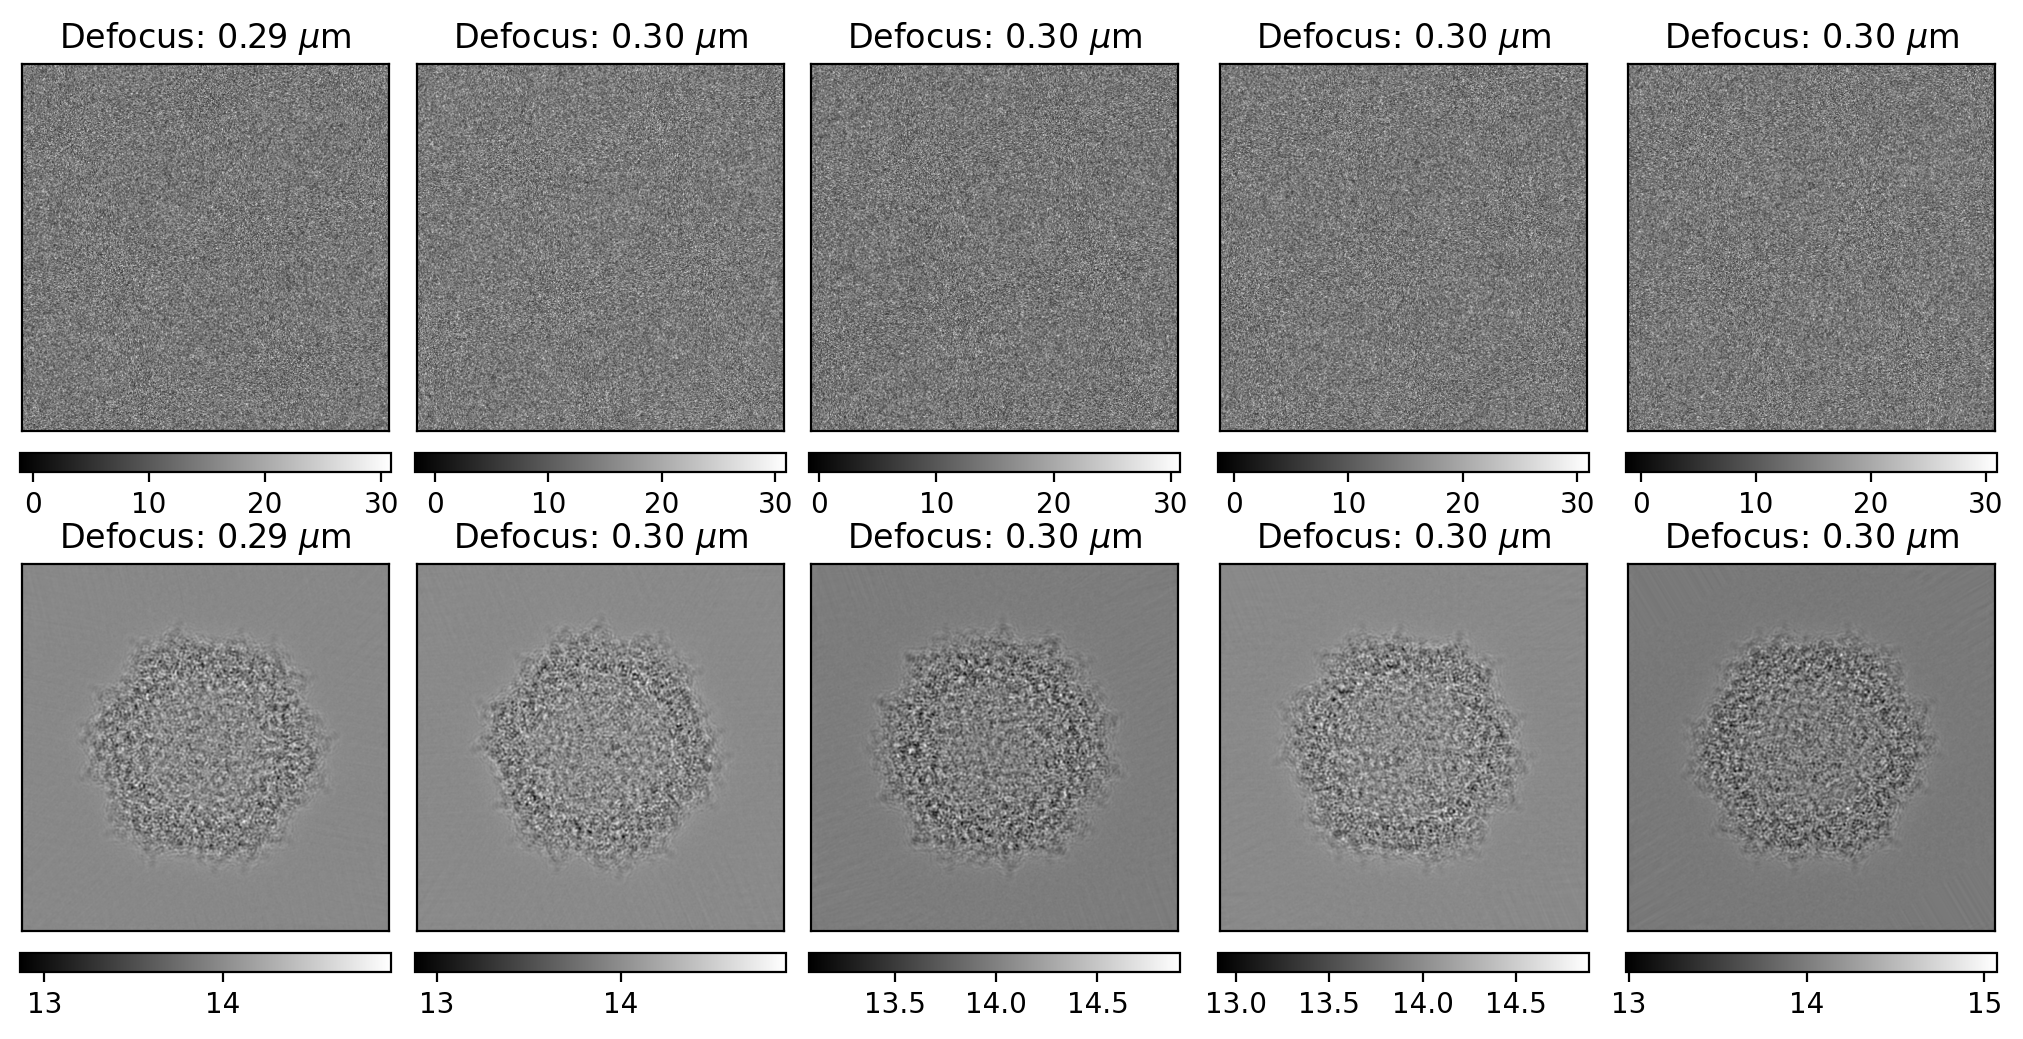

In [13]:
# normalize and flip sign

fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i in range(5):
    ax = axes[0, i]
    im = ax.imshow(images[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params['dfu'][i] / 10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[1, i]
    im = ax.imshow(sim[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params['dfu'][i] / 10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()

In [14]:
model1.imagegenerator.exitwaves.shape

torch.Size([5, 512, 512])

In [68]:
idx = 3
n_points = 500
ctf_batch = {
    k: getattr(model1.imagegenerator, k)[idx]
    for k in model1.imagegenerator._ctf_param_names
}
defocus_offset = torch.linspace(-100, 100, n_points, device=device)
ew = model1.imagegenerator.exitwaves[idx]

In [69]:
error = []
for do in track(defocus_offset):
    ctf_new = ctf_batch.copy()
    ctf_new["dfu"] += do
    ctf_new["dfv"] += do
    det_ew = model1.imagegenerator.aberration(ew, ctf_new)
    im = model1.imagegenerator.detector(det_ew, model1.anisomag[idx], 512)

    # error
    err = torch.mean(torch.abs(im.cpu().detach() - images[idx]) ** 2)
    error.append(err)
error = torch.stack(error)

Working...:   0%|          | 0/500 [00:00<?, ?it/s]

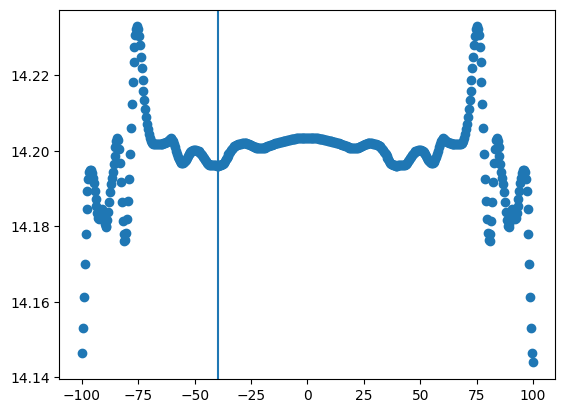

In [70]:
min_idx = error[n_points // 4 : n_points // 4 + n_points // 2].argmin()
plt.scatter(defocus_offset.cpu(), error)
plt.axvline(defocus_offset.cpu()[min_idx + n_points // 4])

In [33]:
images.shape

torch.Size([15257, 512, 512])

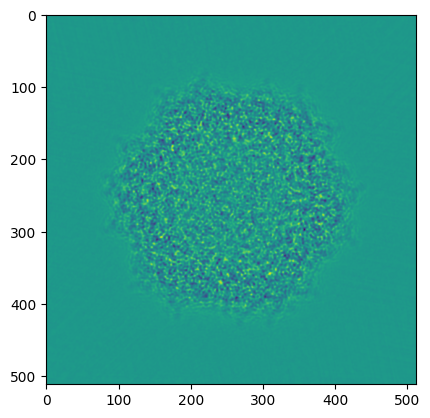

In [26]:
plt.imshow(images.cpu())